In [36]:
import os
import gc

import torch
from torch.optim import Adam

import matplotlib.pyplot as plt

import subprocess

from datetime import datetime
from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import DB_PATH, MODELS
from src.model_selection import get_checkpoints, load_inference_models, create_model_selector
from src.fine_tune.utils import get_device
from src.fine_tune.types import ModelInfo, ModelParameters, TrainingObjects

MODEL_DIR = MODELS / "dino_adapter_block"
os.makedirs(MODEL_DIR, exist_ok=True)

In [37]:
DINO_DIR = MODELS / "dino_fine_tune"

dino_checkpoints = get_checkpoints(DINO_DIR)

Found 11 checkpoints at /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/models/dino_fine_tune


In [ ]:
selector = create_model_selector(dino_checkpoints=dino_checkpoints)

selector.display()

Dropdown(description='DINO:', layout=Layout(width='800px'), options=(('Select a DINO model', 'UNSELECTED'), ('…

Button(button_style='success', description='Confirm selection', layout=Layout(width='180px'), style=ButtonStyl…

Output()

In [40]:
device = get_device()

selected_path = selector.get_selected_path()
pipeline = load_inference_models(selected_path, device=device)

2.12.0+cu130
13.0
True
1
Device: cuda


Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main


Using pretrained DINOv2 ViT-S/14


In [41]:
%load_ext autoreload 
%autoreload 2 

from src.fine_tune.transformer_block import DinoBlockExtension

from src.fine_tune import (
    DataLoading,
    contrastive_transform,
    test_transform,
    Trainer,
    TrainLogger,
    load_dataset_meta,
)

from src.fine_tune.losses.combined_loss import CombinedLoss
from src.fine_tune.losses.anomaly_head import  CategoryAnomalyContrastiveLoss
from src.fine_tune.losses.unsupervised_head import VICRegLoss
from src.fine_tune.losses.types import LossCollection, WeightedLoss, LossName

git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True ).strip()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
data = load_dataset_meta(DB_PATH)

meta = data.meta

train_paths = data.train_paths
test_paths = data.test_paths

categories = data.categories
types = data.types

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

In [43]:
NOTES = [
    "Trained using normal dino",
    "Testing with lr1e-4 due to historical evidence that it worked well before"
]

PARAMS: ModelParameters = {
    "seed": 42,
    "num_workers": 8,
    "pin_memory": device.type == "cuda",
    
    "samples_per_category": 16,
    "batch_size": len(categories) * 16, # * samples_per_category
    "epochs": 20,

    "model_dim": 384,
    "hidden_dim": 384 * 4, # DIM * MLP_FACTOR
    "mlp_factor": 4,
    "dropout": 0.0,
    "model_normaliser": "layer",
    "use_residual": False,

    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    
    "model_name": "model.pt",
}

In [44]:
MODEL_INFO: ModelInfo = {
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : PARAMS,
    "parent_models" : {
        stage.name: str(stage.path) if stage.path is not None else None
        for stage in pipeline
    },
    "negative_indices": [], 
    "model_type": "dino_adapter_block"
}

In [ ]:
loader = DataLoading(root=ROOT, params=PARAMS, categories=categories, types=types)

train_loader, val_loader, mal_loader = loader.create_train_val_loaders(
    train_paths,
    train_transform=contrastive_transform,
    eval_transform=test_transform,
    train_ratio=0.95
)

test_dataset = loader.create_test_dataset(
    test_paths,
    transform=test_transform
)

neg_indices = loader.select_negative_indices(
    test_dataset,
    samples_per_category=5
)
MODEL_INFO["negative_indices"] = neg_indices.tolist()

test_loader = loader.create_test_loader(
    test_dataset,
    excluded_indices=neg_indices
)

neg_images, neg_labels = loader.get_neg_embeds(
    test_dataset,
    neg_indices,
    device
)

In [46]:
model = DinoBlockExtension(dino=pipeline.dino).to(device)

optimizer = Adam(model.parameters(), lr=PARAMS["learning_rate"], weight_decay=PARAMS["weight_decay"])

In [47]:
losses = LossCollection(
    losses=[
        WeightedLoss(
            name=LossName.ANOMALY_CATEGORY_CONTRASTIVE,
            loss=CategoryAnomalyContrastiveLoss(temperature=0.1),
            weight=1.0,
        ),
        WeightedLoss(
            name=LossName.VICREG,
            loss=VICRegLoss(),
            weight=0.0
        )
    ]
)
MODEL_INFO["losses"] = losses.to_dict()

logger = TrainLogger(project="MVTEC OOD", name="DINO Adapter Block", model_info=MODEL_INFO)

criterion = CombinedLoss(losses=losses)
criterion.collect_metrics = logger is not None

training_objs = TrainingObjects(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    negatives=neg_images,
    negative_labels=neg_labels
)

batch/eval/anomaly_contrastive/matched_anomaly,██▇▅▄▃▃▂▁▁▁
batch/eval/anomaly_contrastive/normal,▁▄▄▅▆▇▇█▇██
batch/eval/anomaly_contrastive/other_normal,█▅▃▃▃▃▂▂▁▁▁
batch/eval/calinski_harabasz,▁▄█
batch/eval/davies_bouldin,█▃▁
batch/eval/inter_distance,▁▆█
batch/eval/intra_distance,█▄▁
batch/eval/loss/anomaly_category_contrastive,█▆▅▃▃▂▁▁▁▁▁
batch/eval/loss/total,█▆▅▃▃▂▁▁▁▁▁
batch/eval/silhouette,▁▆█
+207,...


In [ ]:
trainer = Trainer(objs=training_objs, pipeline=pipeline, logger=logger)

results = trainer.train_model(
    epochs=PARAMS["epochs"], 
    train_loader=train_loader,
    val_loader=val_loader
)

try:
    trainer.save_results(
        results=results,
        MODEL_DIR=MODEL_DIR,
        MODEL_INFO=MODEL_INFO,
        timestamp=timestamp
    )

    test_metrics = trainer.test(
        mahalanobis_loader=mal_loader,
        test_loader=test_loader,
        types_to_id=loader.types_to_id,
        cat_to_id=loader.cat_to_id
    )
finally:
    del trainer

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if results.error is not None:
    raise results.error

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Output()

Best Model Saved (val_loss=3.4424) as epoch 12


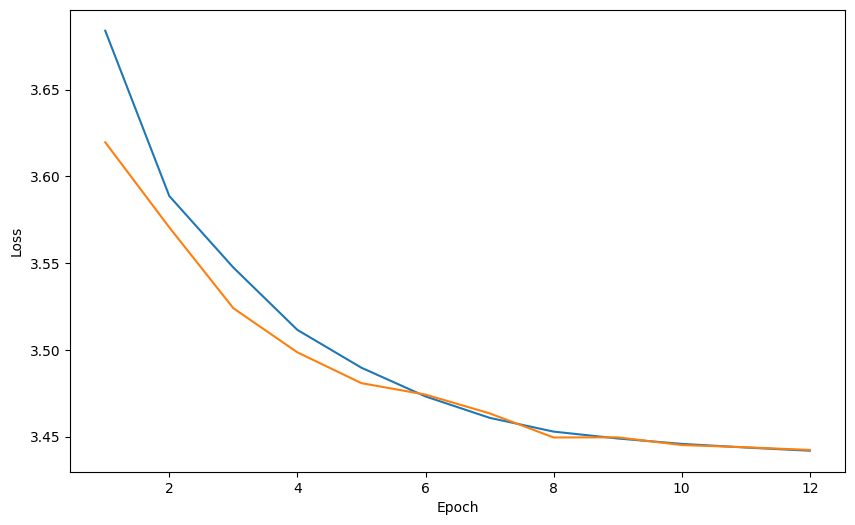

In [49]:
fig = plt.figure(figsize=(10, 6))

plt.plot(results.history["epoch"], results.history["train_loss"])
plt.plot(results.history["epoch"], results.history["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()

In [ ]:
test_metrics

test/category/silhouette                       0.511773
test/category/davies_bouldin                   0.905464
test/category/calinski_harabasz              399.632143
test/category/intra_distance                   8.168267
test/category/inter_distance                   4.306285
                                                ...    
test/mean/normal_defect/silhouette             0.246584
test/mean/normal_defect/davies_bouldin         1.254467
test/mean/normal_defect/calinski_harabasz     54.085971
test/mean/normal_defect/intra_distance         6.544318
test/mean/normal_defect/inter_distance         0.574925
Length: 181, dtype: float64

: 